# Option pricing via Fast fourrier and COS method

## idea

1. Assuming that $\phi(u)$ is the characteristic function of the random variable $X$ we can recover the density function via <br><br>
$$f(x) =  \dfrac{1}{\pi}\mathscr{R}\left[\int_{0}^{+\infty}e^{-iux}\phi(u)du \right] $$

1. Now if we let $f(x)$ be the density function of $X_T$ we

1. When pricing derivatives by the fundamental theorem of asset pricing we need to compute the expectation<br>
$\begin{align}
V(t, X_t) &= \mathbb{E^Q}\left[  \dfrac{V(T, X_T)} {M(T} \right] \\
          &= \int_{-\infty}^{+\infty}\dfrac{V(T, x)} {M(T)} \color{blue} {f(x)} dx \\
          &=  \int_{-\infty}^{+\infty}\dfrac{V(T, x)} {M(T)} \color{blue} {\dfrac{1}{\pi}\mathscr{R}\left[\int_{0}^{+\infty}e^{-iux}\phi(u)du \right]} dx
\end{align}
$ 
<br>

1. We clearly see here that there is a need to compute a 2 integrals 
    * One intergral over the domain of $x$ 
    * One integral over the domain of $u$
    <BR><BR>
    
1. If we discretize the domain of $X$ into $N$ discrete points and the domain of $u$ to $N$ discrete points then the total number of operations is alrealy $\mathscr{O}(N^2)$

1. However thanks to an algoritmn called Fast Fourrier Transform we can bring this down to $\mathscr{O}(N log N)$


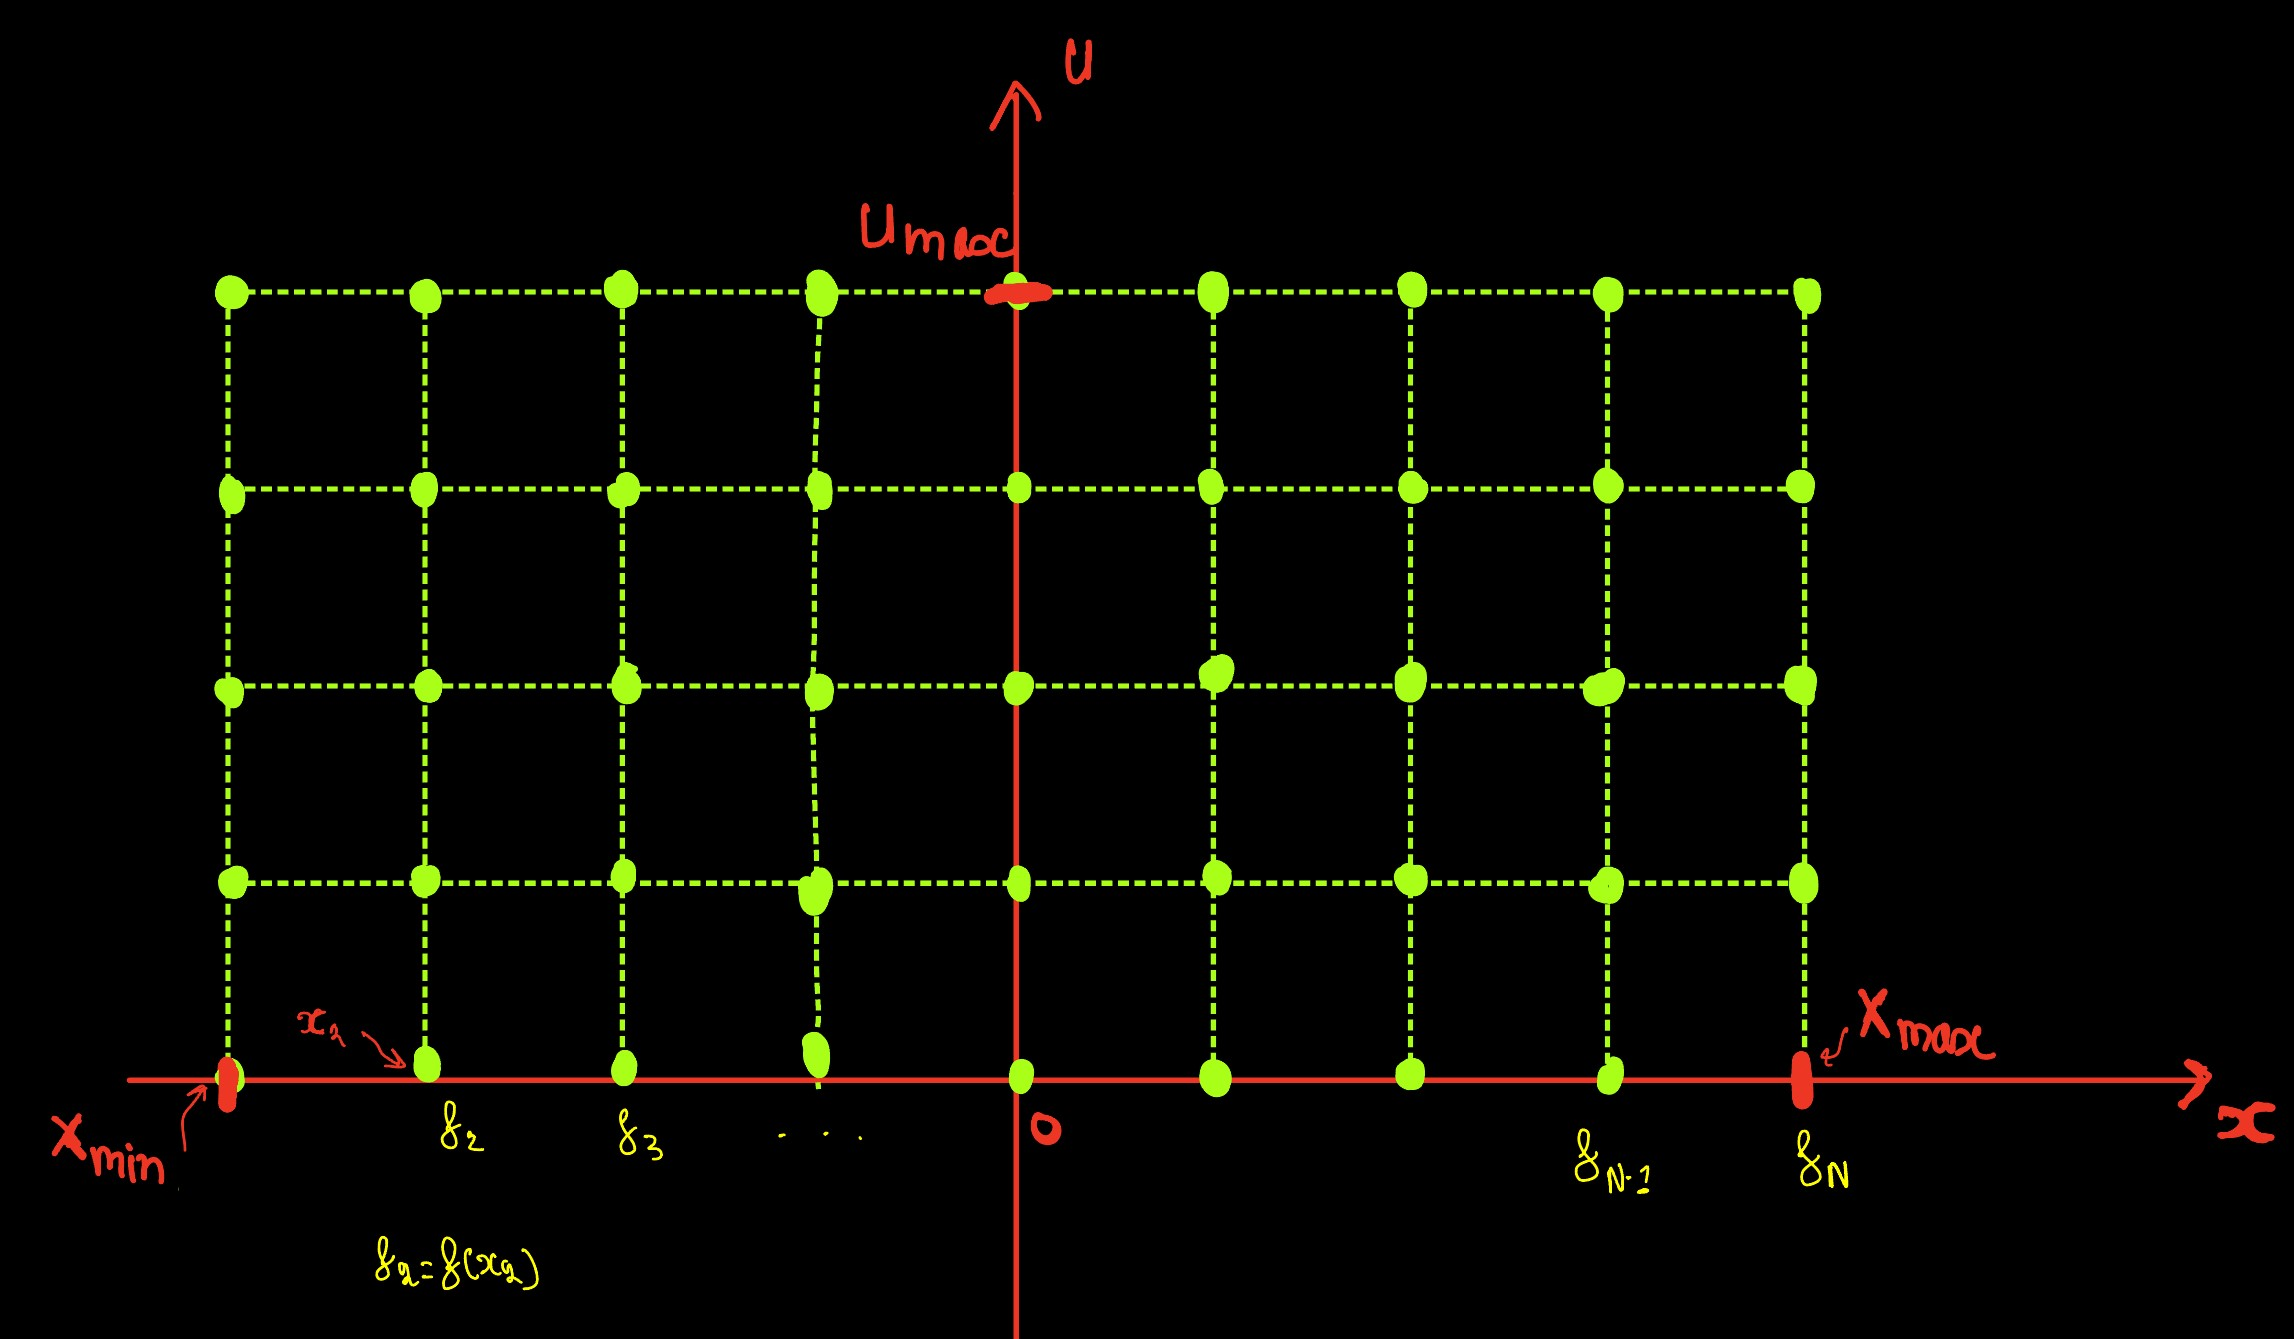

##  Density recovery Fast Fourrier Transform (FFT) method


1. By discretization of the $u$ and $x$ domain into grids of N point we can find the density at those discrete point using Fast Fourrier transform
$$
 \begin{align}
     f(x_k) = f_k &= \dfrac{\Delta_u}{\pi} \mathbf{R} \left\{ \sum_{n=1}^{N}exp\left(-i\frac{2\pi}{N}(n-1)(k-1)\right)\times exp\left(i x_{min} u_n\right)\phi(u_n)       - \dfrac{1}{2}(\gamma_1 + \gamma_2)     \right\} \\
\end{align}
$$<br><br>
where : <br>
$
 \begin{align}
 N &= \text{number of points in which we discretize the domain for } u \text{ and } x \\
 x_{min} &= \text{low enough value of X can take}\\
 u_{max} &= N\Delta_u \\
 u_n &= (n-1)\Delta_u \\
 x_k &=x_{min} + \Delta_x (k-1)\\
 \Delta_x\Delta_u &= \frac{2\pi}{N}\\
 \gamma_1 &=  e^{-ix_ku_1}\phi(u_1) \\
 \gamma_2  &= e^{-ix_ku_N}\phi(u_N) \\
\end{align}
$


##  Example  Normal density recovery using FFT


The characteristic function of the Normal distribution is given by 

$$\phi_X(u) = exp(i\mu u - 0.5\sigma^2 u^2)$$

len un = 8.0


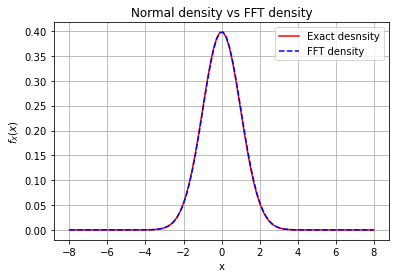

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import scipy.fft as fft
import scipy.interpolate as interpolate

# define the complex number i
i = complex(0.0, 1.0)
π = np.pi

def RecoverDensity(φ, x, N= 8000, u_max = 20 ):
    # specification for the grids of u
    Δ_u = u_max / N 
    u_n = np.linspace(0,N,N)*Δ_u

    # specification for the grid of x
    x_min = min(x)
    Δ_x = 2*π/N *1/Δ_u 
    x_n = x_min + np.linspace(0,N,N)*Δ_x

    # get the recovered density via FFT
    γ_1 = np.exp(-i*x_n*u_n[0])*φ(u_n[0])
    γ_2 = np.exp(-i*x_n*u_n[-1])*φ(u_n[-1])
    γ = 0.5 * (γ_1 + γ_2)  
    
    print(f"len un = {x[-1]}")

    # compute FFT 
    phi = np.exp(-i*x_min*u_n)*φ(u_n)
    f_x_n = Δ_u/π * np.real( fft.fft(phi) - γ )
    f_x_fft =  interpolate.interp1d(x_n,f_x_n,kind='cubic') 
    return f_x_fft(x)



# setting for normal distribution
μ = 0
σ = 1

# define the characteristic function of the normal distribution
φ = lambda u : np.exp(i*u*μ -0.5*σ**2*u**2)

# define the domain for density
x = np.linspace(-8.0, 8.0, 100)

# get the exact density at the point x
f_x_exact = st.norm.pdf(x, μ, σ)

# number of grid point 
N = 1000
u_max = 40

# get the fft density at the point x
f_recovered = RecoverDensity(φ, x, N, u_max)

# plots
plt.figure(1)
plt.grid()
plt.xlabel("x")
plt.ylabel("$f_X(x)$")
plt.plot(x,f_x_exact,'-r', label = 'Exact desnsity')
plt.plot(x,f_recovered,'--b', label = 'FFT density')
plt.title('Normal density vs FFT density')
plt.legend();

## Fourier Cosine Expansion : COS Method


###  Introduction



First it is important to understand the advantages of the COS method
* It allows exponential convergence to recover the density functions
* Greeks are obtained at no additional cost
* In FFT we needed a $N \times N$ grid but with the COS method we required much less

The basic idea is to replace the density by its Fourrier-cosine series expansion.

for a random variable $X$ the density $f(x)$ and the characteristic function $\phi(u)$ form a fourrier pair

$$
 \begin{align}
 \phi(u) &=\int_{-\infty}^{+\infty}e^{iux}f(x)dx\\
 \\
  f(x) &= \dfrac{1}{2\pi}\int_{-\infty}^{+\infty}e^{-iux}\phi(u)du \\ 
\end{align}
$$


###  COS method to recover density 

The Fourier-Cosine expansion of density function on the interval $[a, b]$ is given by 

$$f(x) = \sum_{n=0}^{'\infty} F_n cos\left( \frac{n\pi}{b-a}(x-a) \right)$$

Note in this expression **the first term MUST be multiplied by 1/2**

The coefficients are defined as 

$$F_n := \dfrac{2}{b-a}\mathbf{R} \left\{  \phi\left( \dfrac{n\pi}{b-a} \right) exp\left( -i\dfrac{n\pi}{b-a}a\right) \right\}$$

###  example recover density of normal distribution


For 4 expanansion terms the max error is 0.2537377837565189
For 8 expanansion terms the max error is 0.10751732725194052
For 16 expanansion terms the max error is 0.007172377614980574
For 32 expanansion terms the max error is 4.032340789605904e-07
For 64 expanansion terms the max error is 2.472026945715902e-16


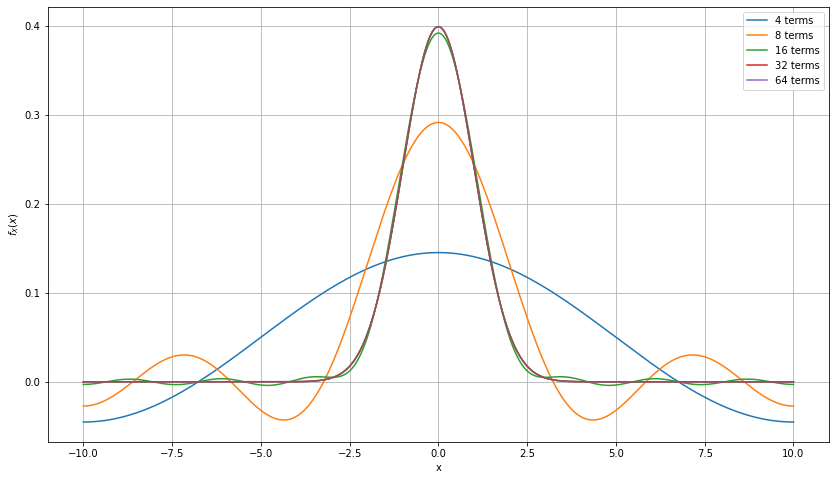

In [95]:
"""
Normal density recovery using the COS method
"""
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

def COSDensity(φ,x,N,a,b):
    i = complex(0.0,1.0) #assigning i=sqrt(-1)
    n = np.linspace(0,N-1,N)
    u = np.zeros([1,N])
    u = n * π / (b-a)
        
    #F_n coefficients
    F_n    = 2.0 / (b - a) * np.real(φ(u) * np.exp(-i * u * a));
    F_n[0] = F_n[0] * 0.5; # adjustment for the first term
    
    #Final calculation
    f_X = np.matmul(F_n , np.cos(np.outer(u, x - a )))
        
    return f_X


i = complex(0.0, 1.0) #assigning i=sqrt(-1)

# setting for the COS method 
a = -10.0
b = 10.0

#define the range for the expansion points
N =[4, 8, 16, 32, 64]

# setting for normal distribution
μ = 0
σ = 1

# define the characteristic function of the normal distribution
φ = lambda u : np.exp(i*u*μ -0.5*σ**2*u**2)

# define domain for density
x = np.linspace(a, b,1000)
f_XExact = st.norm.pdf(x,μ,σ)

plt.figure(1,figsize=(14,8))
plt.grid()
plt.xlabel("x")
plt.ylabel("$f_X(x)$")
for n in N:
    f_X = COSDensity(φ,x,n,a,b)
    error = np.max(np.abs(f_X-f_XExact))
    print("For {0} expanansion terms the max error is {1}".format(n,error))

    plt.plot(x,f_X, label = f"{n} terms")
plt.plot(x,f_XExact)
plt.legend()


###  example recover density of log normal distribution


Let $Y$ be a lognormal random variable and $X = log(Y)$ is Normal

we have  the density function of Y is : 

$$f_Y(y) =  \dfrac{1}{y} f_X(log(y))$$

By the COS method we can recover the density of the log normal distribution


For 16 expanansion terms the max error is 1.2881346097751576
For 64 expanansion terms the max error is 0.1744162291981549
For 128 expanansion terms the max error is 0.0004668102602748206
For 1000 expanansion terms the max error is 1.6363691918545738e-14


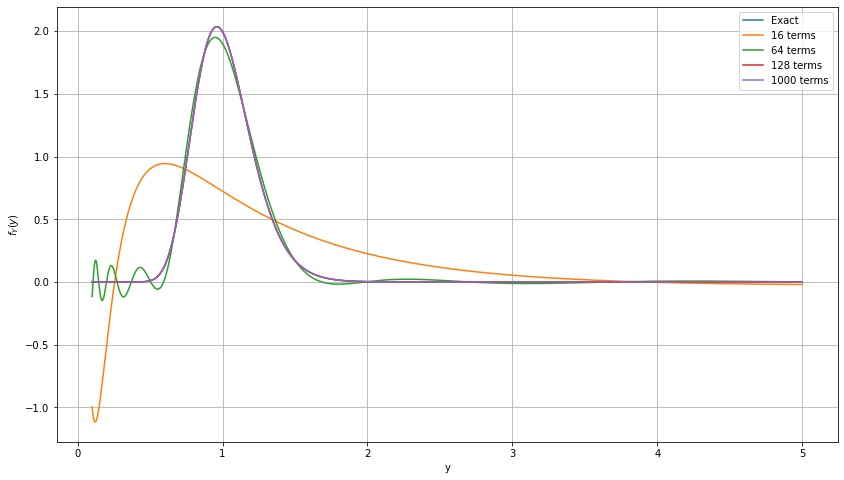

In [111]:
i = complex(0.0, 1.0) #assigning i=sqrt(-1)

# setting for the COS method 
a = -10.0
b = 10.0

#define the range for the expansion points
N =[16,64,128, 1000 ]

# setting for normal distribution
μ = 0
σ = 0.2

# define the characteristic function of the normal distribution
φ = lambda u : np.exp(i*u*μ -0.5*σ**2*u**2)

# define domain for density
y = np.linspace(0.1,5,1000)

# get exaxct log normal distribution
ln_object= st.lognorm(s=σ, loc=0, scale=np.exp(μ)) # instantiate log-norm distribution object
f_YExact = ln_object.pdf(y) # calculate log-norm PDF


plt.figure(1,figsize=(14,8))
plt.grid()
plt.xlabel("y")
plt.ylabel("$f_Y(y)$")

plt.plot(y,f_YExact, label = 'Exact')
for n in N:
    f_Y = 1/y * COSDensity(φ,np.log(y),n,a,b)
    error = np.max(np.abs(f_Y-f_YExact))
    print("For {0} expanansion terms the max error is {1}".format(n,error))
    plt.plot(y,f_Y, label = f'{n} terms')
plt.legend()


## COS methOd for european options pricing

1. the COS method for European option pricing is obtained by subtutiting the density function by its COS representation

1. by substitution by the cos expansion we have  <br><br>
$$V(t,X_t) = e^{-r\tau}\sum_{n=0}^{N-1}'H_n\mathbf{R} \left\{  \phi\left( \dfrac{n\pi}{b-a} \right) exp\left( -i\dfrac{n\pi}{b-a}a\right) \right\}$$
Where 
    * $\tau = T - t$
    * $X_t$ is a function of $S(t_0)$ like $log S(t_0)$
    * $\phi_X(u)$ the characteristic function of x
    * $H_k$ is known analytically for plain vanilla and digital options
<br><br>

    
1. The option cofficients are 
    * Call option coefficient are given by $$H_k^{call} = \dfrac{2}{b-1}K \left(  \chi_k(0, b) - \psi_k (0,b)  \right)$$
    * Put option coefficient are given by  $$H_k^{put} = \dfrac{2}{b-1}K \left(  - \chi_k(a, 0) - \psi_k (a,0)  \right)$$



It took 2.0565986633300782e-05 seconds to price.
Abs error for strike 80.0 is equal to 1.31E-07
Abs error for strike 90.0 is equal to 3.93E-07
Abs error for strike 100.0 is equal to 3.87E-07
Abs error for strike 110 is equal to 4.32E-07
Abs error for strike 120.0 is equal to 3.50E-07


C:\Users\wb548956\AppData\Local\Temp/ipykernel_52636/511389856.py:106: DeprecationWarning: `np.complex` is a deprecated alias for the builtin `complex`. To silence this warning, use `complex` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.complex128` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  i = np.complex(0.0,1.0)
C:\Users\wb548956\AppData\Local\Temp/ipykernel_52636/511389856.py:26: DeprecationWarning: `np.complex` is a deprecated alias for the builtin `complex`. To silence this warning, use `complex` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.complex128` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  i = np.complex(0.0,1.0)


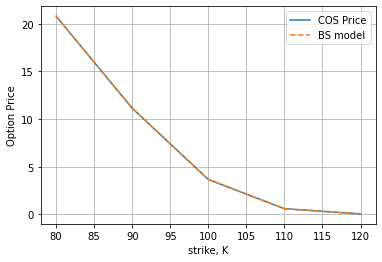

In [1]:
#%%
"""
Created on Thu Nov 27 2018
Pricing of European Call and Put options wit the COS method
@author: Lech A. Grzelak
"""
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import time

def CallPutOptionPriceCOSMthd(φ,CP,S0,r,τ,K,N,L):
    # φ   - characteristic function as a functon, in the book denoted as \varphi
    # CP   - C for call and P for put
    # S0   - Initial stock price
    # r    - interest rate (constant)
    # τ  - time to maturity
    # K    - list of strikes
    # N    - Number of expansion terms
    # L    - size of truncation domain (typ.:L=8 or L=10)  
        
    # reshape K to a column vector
    K = np.array(K).reshape([len(K),1])
    
    #assigning i=sqrt(-1)
    i = np.complex(0.0,1.0) 
    
    x0 = np.log(S0 / K)   
    
    # truncation domain
    a = 0.0 - L * np.sqrt(τ)
    b = 0.0 + L * np.sqrt(τ)
    
    # sumation from k = 0 to k=N-1
    k = np.linspace(0,N-1,N).reshape([N,1])  
    u = k * np.pi / (b - a);  

    # Determine coefficients for Put Prices  
    H_k = CallPutCoefficients(CP,a,b,k)
       
    mat = np.exp(i * np.outer((x0 - a) , u))

    temp = φ(u) * H_k 
    temp[0] = 0.5 * temp[0]    
    
    value = np.exp(-r * τ) * K * np.real(mat.dot(temp))
         
    return value

""" 
Determine coefficients for Put Prices 
"""
def CallPutCoefficients(CP,a,b,k):
    if str(CP).lower()=="c" or str(CP).lower()=="1":                  
        c = 0.0
        d = b
        coef = Chi_Psi(a,b,c,d,k)
        Chi_k = coef["chi"]
        Psi_k = coef["psi"]
        if a < b and b < 0.0:
            H_k = np.zeros([len(k),1])
        else:
            H_k      = 2.0 / (b - a) * (Chi_k - Psi_k)  
        
    elif str(CP).lower()=="p" or str(CP).lower()=="-1":
        c = a
        d = 0.0
        coef = Chi_Psi(a,b,c,d,k)
        Chi_k = coef["chi"]
        Psi_k = coef["psi"]
        H_k      = 2.0 / (b - a) * (- Chi_k + Psi_k)               
    
    return H_k    

def Chi_Psi(a,b,c,d,k):
    psi = np.sin(k * np.pi * (d - a) / (b - a)) - np.sin(k * np.pi * (c - a)/(b - a))
    psi[1:] = psi[1:] * (b - a) / (k[1:] * np.pi)
    psi[0] = d - c
    
    chi = 1.0 / (1.0 + np.power((k * np.pi / (b - a)) , 2.0)) 
    expr1 = np.cos(k * np.pi * (d - a)/(b - a)) * np.exp(d)  - np.cos(k * np.pi 
                  * (c - a) / (b - a)) * np.exp(c)
    expr2 = k * np.pi / (b - a) * np.sin(k * np.pi * 
                        (d - a) / (b - a))   - k * np.pi / (b - a) * np.sin(k 
                        * np.pi * (c - a) / (b - a)) * np.exp(c)
    chi = chi * (expr1 + expr2)
    
    value = {"chi":chi,"psi":psi }
    return value
    

def BS_Call_Option_Price(CP,S_0,K,sigma,tau,r):
    #Black-Scholes Call option price
    cp = str(CP).lower()
    K = np.array(K).reshape([len(K),1])
    d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) 
    * tau) / float(sigma * np.sqrt(tau))
    d2    = d1 - sigma * np.sqrt(tau)
    if cp == "c" or cp == "1":
        value = st.norm.cdf(d1) * S_0 - st.norm.cdf(d2) * K * np.exp(-r * tau)
    elif cp == "p" or cp =="-1":
        value = st.norm.cdf(-d2) * K * np.exp(-r * tau) - st.norm.cdf(-d1)*S_0
    return value

def mainCalculation():
    i = np.complex(0.0,1.0)
    
    CP = "c"
    S0 = 100.0
    r = 0.1
    tau = 0.1
    sigma = 0.25
    K = [80.0, 90.0, 100.0, 110, 120.0]
    N = 4*32
    L = 10
    
    # Definition of the characteristic function for the GBM, this is an input
    # for the COS method
    # Note that Chf does not include coefficient "+iuX(t_0)" this coefficient
    # is included internally in the evaluation
    # In the book we denote this function as \varphi(u)

    cf = lambda u: np.exp((r - 0.5 * np.power(sigma,2.0)) * i * u * tau - 0.5 
                          * np.power(sigma, 2.0) * np.power(u, 2.0) * tau)
    
    # Timing results 
    NoOfIterations = 100
    time_start = time.time() 
    val_COS = CallPutOptionPriceCOSMthd(cf,CP,S0,r,tau,K,N,L)
    time_stop = time.time()
    print("It took {0} seconds to price.".format((time_stop-time_start)/float(NoOfIterations)))
    
    # evaluate analytical Black Scholes equation
    val_Exact = BS_Call_Option_Price(CP,S0,K,sigma,tau,r)
    plt.plot(K,val_COS)
    plt.plot(K,val_Exact,'--')
    plt.xlabel("strike, K")
    plt.ylabel("Option Price")
    plt.legend(["COS Price","BS model"])
    plt.grid()    
    
    #Error comuputation
    error = []
    for i in range(0,len(K)):
        error.append(np.abs(val_COS[i]-val_Exact[i])[0])
        print("Abs error for strike {0} is equal to {1:.2E}".format(K[i],error[i]))
        
mainCalculation()